In [1]:
!pip uninstall -y timm
!pip install -q timm==0.6.7

Found existing installation: timm 1.0.25
Uninstalling timm-1.0.25:
  Successfully uninstalled timm-1.0.25
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.0/510.0 kB 16.1 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Recommended by the ZoeDepth README before loading ZoeDepth
torch.hub.help("intel-isl/MiDaS", "DPT_BEiT_L_384", force_reload=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "ZoeD_NK"   # options: ZoeD_N, ZoeD_K, ZoeD_NK

print("Device:", DEVICE)
print("Loading model:", MODEL_NAME)

zoe = torch.hub.load("isl-org/ZoeDepth", MODEL_NAME, pretrained=True)
zoe = zoe.to(DEVICE)
zoe.eval()

print("Model loaded.")

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to help(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or help(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use help(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip
Device: cpu
Loading model: ZoeD_NK


/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/isl-org/ZoeDepth/zipball/main" to /root/.cache/torch/hub/main.zip
img_size [384, 512]


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Params passed to Resize transform:
	width:  512
	height:  384
	resize_target:  True
	keep_aspect_ratio:  True
	ensure_multiple_of:  32
	resize_method:  minimal
Using pretrained resource url::https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_NK.pt
Downloading: "https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_NK.pt" to /root/.cache/torch/hub/checkpoints/ZoeD_M12_NK.pt


/root/.cache/torch/hub/isl-org_ZoeDepth_main/zoedepth/models/layers/patch_transformer.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(
100%|██████████| 1.35G/1.35G [00:44<00:00, 32.8MB/s]


Loaded successfully
Model loaded.


In [3]:
from zoedepth.utils.misc import save_raw_16bit, colorize


image_path = "IMG_1726.JPG"
# Load image
image = Image.open(image_path).convert("RGB")

# Predict metric depth
with torch.no_grad():
    depth = zoe.infer_pil(image)   # numpy array, in meters

depth = np.asarray(depth, dtype=np.float32)

print("Depth shape:", depth.shape)
print("Min depth (m):", float(np.nanmin(depth)))
print("Max depth (m):", float(np.nanmax(depth)))
print("Mean depth (m):", float(np.nanmean(depth)))

# Output folder
out_dir = "zoe_output"
os.makedirs(out_dir, exist_ok=True)

base = os.path.splitext(os.path.basename(image_path))[0]

npy_path = os.path.join(out_dir, f"{base}_depth.npy")
raw16_path = os.path.join(out_dir, f"{base}_depth_raw16.png")
color_path = os.path.join(out_dir, f"{base}_depth_color.png")

# Save raw metric depth array
np.save(npy_path, depth)

# Save 16-bit PNG using official helper
save_raw_16bit(depth, raw16_path)

# Save colorized depth using official helper
colored = colorize(depth)
Image.fromarray(colored).save(color_path)

print("Saved:", npy_path)
print("Saved:", raw16_path)
print("Saved:", color_path)

Depth shape: (3456, 5184)
Min depth (m): 3.899129867553711
Max depth (m): 23.015287399291992
Mean depth (m): 8.094557762145996
Saved raw depth to zoe_output/IMG_1726_depth_raw16.png
Saved: zoe_output/IMG_1726_depth.npy
Saved: zoe_output/IMG_1726_depth_raw16.png
Saved: zoe_output/IMG_1726_depth_color.png


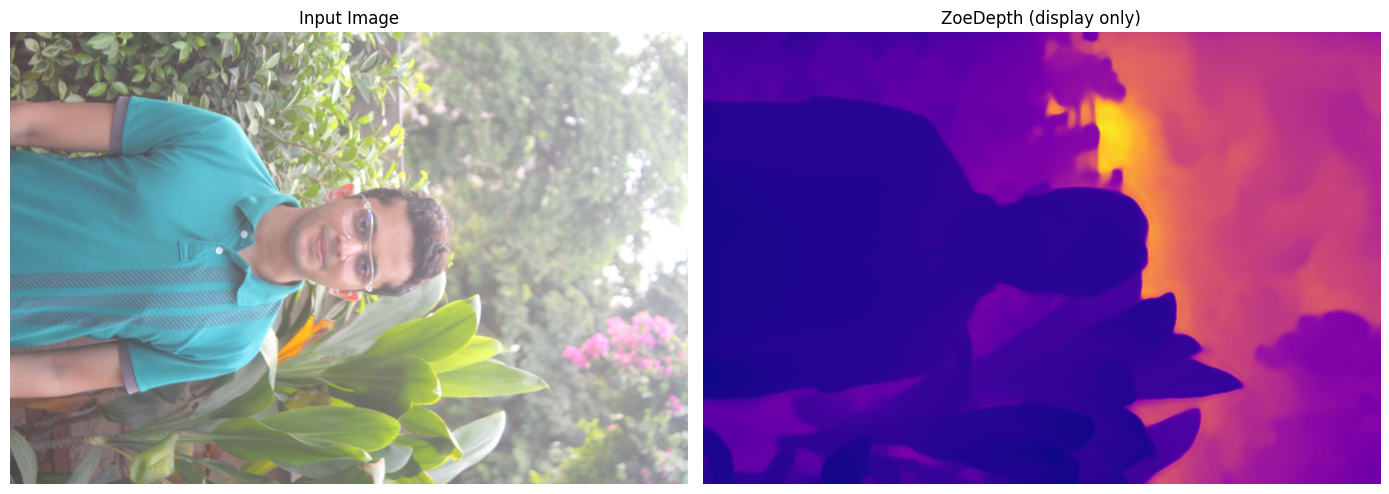

In [4]:
def normalize_for_display(depth_map):
    depth_map = np.asarray(depth_map, dtype=np.float32)
    dmin = np.nanmin(depth_map)
    dmax = np.nanmax(depth_map)
    return (depth_map - dmin) / (dmax - dmin + 1e-8)

depth_vis = normalize_for_display(depth)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(depth_vis, cmap="plasma")
plt.title("ZoeDepth (display only)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
%matplotlib notebook

fig, ax = plt.subplots(figsize=(7, 9))
ax.imshow(image)
ax.set_title("Click a pixel to read predicted depth (meters)")

def onclick(event):
    if event.xdata is None or event.ydata is None:
        return

    x = int(round(event.xdata))
    y = int(round(event.ydata))

    if 0 <= x < depth.shape[1] and 0 <= y < depth.shape[0]:
        d = float(depth[y, x])
        print(f"Pixel (x={x}, y={y}) -> predicted depth = {d:.3f} m")

cid = fig.canvas.mpl_connect("button_press_event", onclick)
plt.show()

<IPython.core.display.Javascript object>

In [6]:
from google.colab import files

files.download(npy_path)
files.download(raw16_path)
files.download(color_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print(os.getcwd())
print(os.listdir("."))
print(os.path.exists("IMG_1726.JPG"))

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1) Load model
model_type = "DPT_Large"   # or "DPT_Hybrid", "MiDaS_small"
midas = torch.hub.load("intel-isl/MiDaS", model_type)

# 2) Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
midas.to(device)
midas.eval()

# 3) Load transforms
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = (
    midas_transforms.dpt_transform
    if model_type in ["DPT_Large", "DPT_Hybrid"]
    else midas_transforms.small_transform
)

# 4) Read image
img_path = "IMG_1726.JPG"

print("Current working dir:", os.getcwd())
print("File exists:", os.path.exists(img_path))

img_bgr = cv2.imread(img_path)

if img_bgr is None:
    raise FileNotFoundError(
        f"Could not read image: {img_path}\n"
        f"Current directory: {os.getcwd()}\n"
        f"Try using the full file path."
    )

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 5) Preprocess
input_batch = transform(img_rgb).to(device)

# 6) Inference
with torch.no_grad():
    prediction = midas(input_batch)
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img_rgb.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

depth = prediction.cpu().numpy()

# 7) Normalize for display
depth_vis = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)

# 8) Show
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(depth_vis, cmap="plasma")
plt.title("MiDaS Depth")
plt.axis("off")

plt.tight_layout()
plt.show()